In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.0 MB/s eta 0:00:00997.9 kB/s eta 0:00:01


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [8]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [12]:
df.shape

(1338, 7)

In [14]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [16]:
df.duplicated().sum()

1

In [18]:
df = df.drop_duplicates()

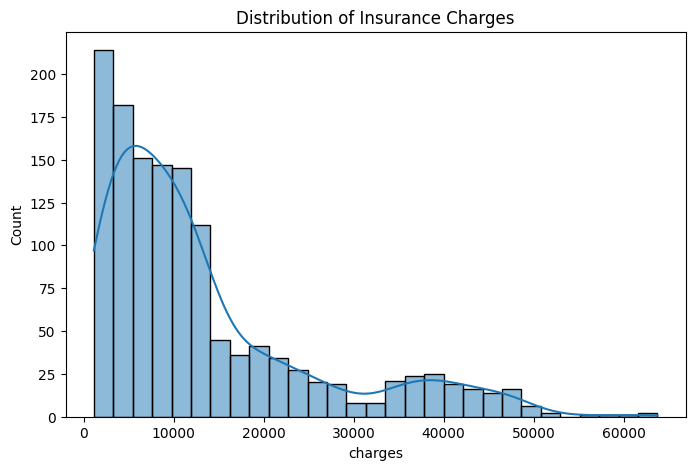

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)

plt.title("Distribution of Insurance Charges")
plt.show()

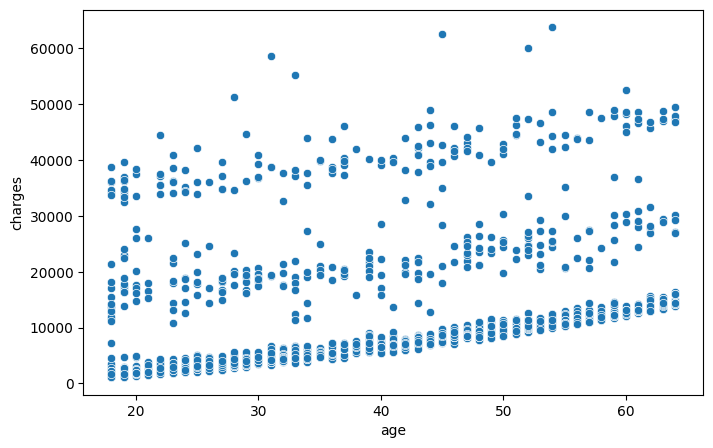

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="age",
    y="charges",
    data=df
)

plt.show()

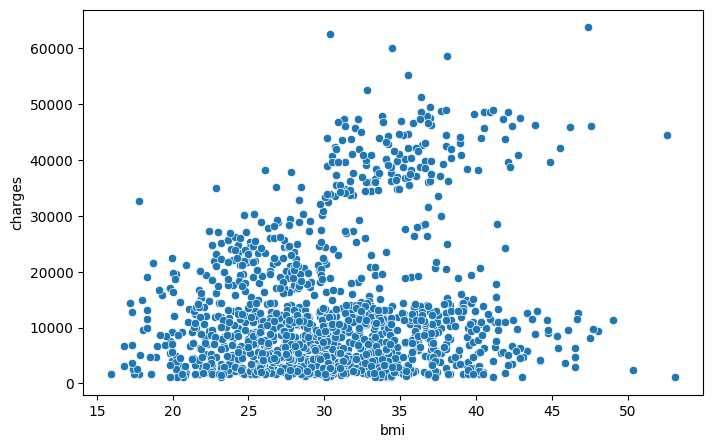

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="bmi",
    y="charges",
    data=df
)

plt.show()

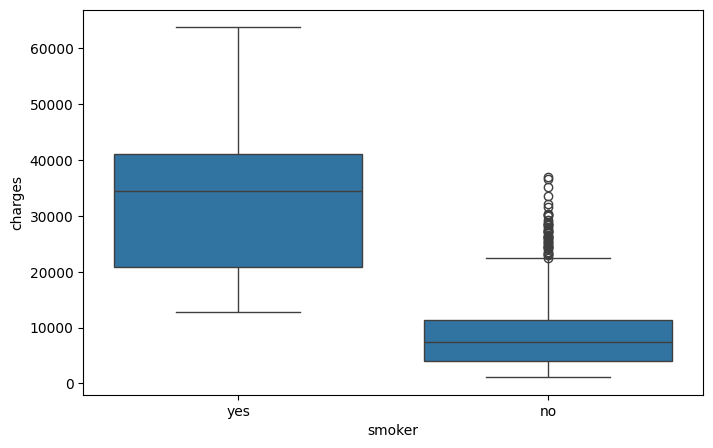

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="smoker",
    y="charges",
    data=df
)

plt.show()

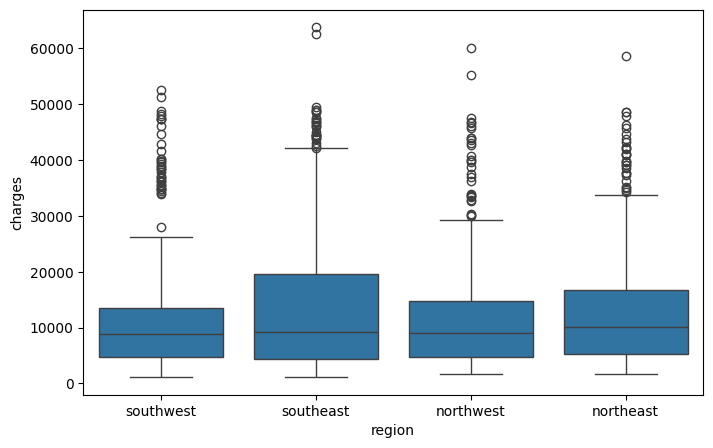

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="region",
    y="charges",
    data=df
)

plt.show()

In [30]:
temp = df.copy()

le = LabelEncoder()

temp["sex"] = le.fit_transform(temp["sex"])
temp["smoker"] = le.fit_transform(temp["smoker"])
temp["region"] = le.fit_transform(temp["region"])

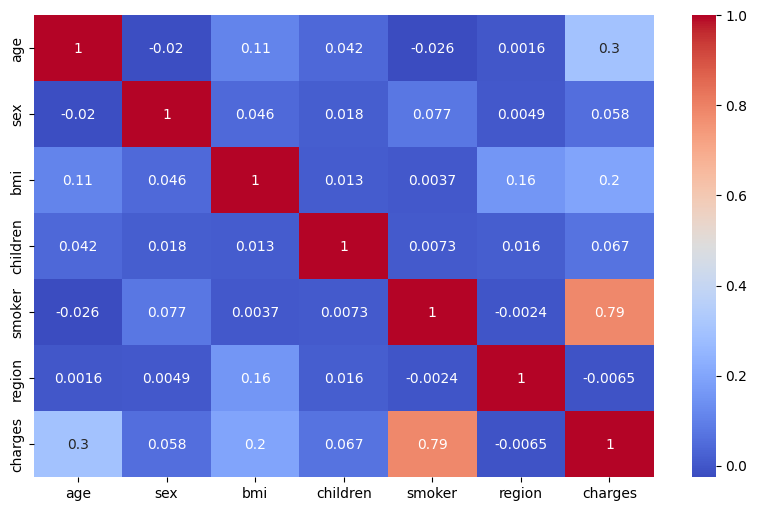

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(
    temp.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

Feature Engineering

In [35]:
#One Hot Encoding
df = pd.get_dummies(
    df,
    columns=["sex","smoker","region"],
    drop_first=True
)

In [37]:
X = df.drop("charges", axis=1)

y = df["charges"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(random_state=42),

    "Gradient Boosting": GradientBoostingRegressor(random_state=42),

    "XGBoost": XGBRegressor(random_state=42)
}

In [47]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test,y_pred)

    rmse = np.sqrt(mean_squared_error(y_test,y_pred))

    r2 = r2_score(y_test,y_pred)

    results.append([name, mae, rmse, r2])

In [49]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,2517.467831,4268.283018,0.900856
2,Random Forest,2640.389231,4705.030236,0.879529
4,XGBoost,2922.399640,4978.596183,0.865112
1,Decision Tree,2730.629849,5769.014181,0.818882
0,Linear Regression,4177.045561,5956.342894,0.806929


Now as Gradient Boostin has highest R2 score then, we will use it as our final model, but before that we will do some tuning.

In [51]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

In [55]:
grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], 'subsample': [0.8, 1.0]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [56]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [59]:
best_gb = grid.best_estimator_

In [61]:
y_pred = best_gb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 2491.1413313863295
MSE : 17891925.931310184
RMSE: 4229.884860289956
R2 Score: 0.9026321878155356


In [63]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_gb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
4,smoker_yes,0.675602
1,bmi,0.184615
0,age,0.123173
2,children,0.014197
3,sex_male,0.001166
7,region_southwest,0.000999
6,region_southeast,0.000169
5,region_northwest,0.000079


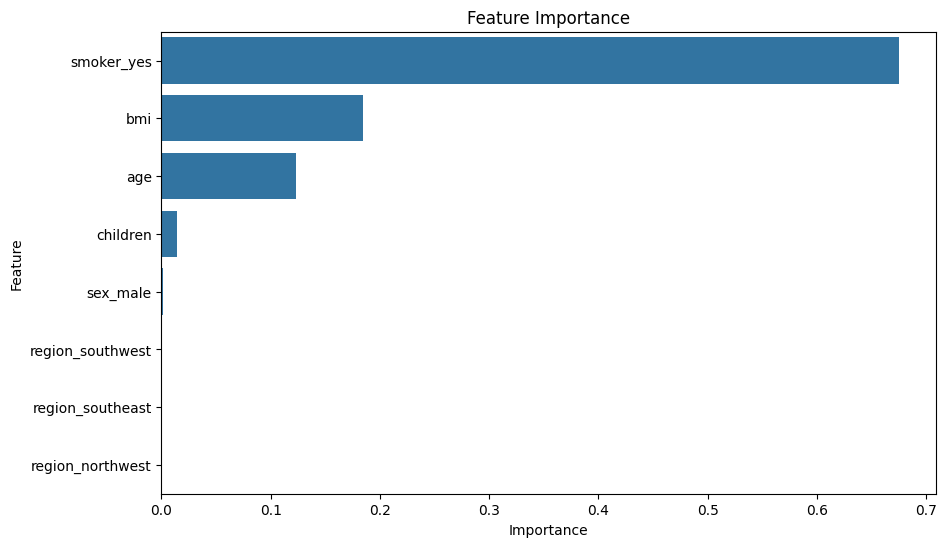

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

In [67]:
import joblib

joblib.dump(best_gb, "healthcare_cost_model.pkl")

['healthcare_cost_model.pkl']

In [69]:
!pip install shap

In [71]:
import shap

In [73]:
explainer = shap.Explainer(best_gb)

shap_values = explainer(X_test)

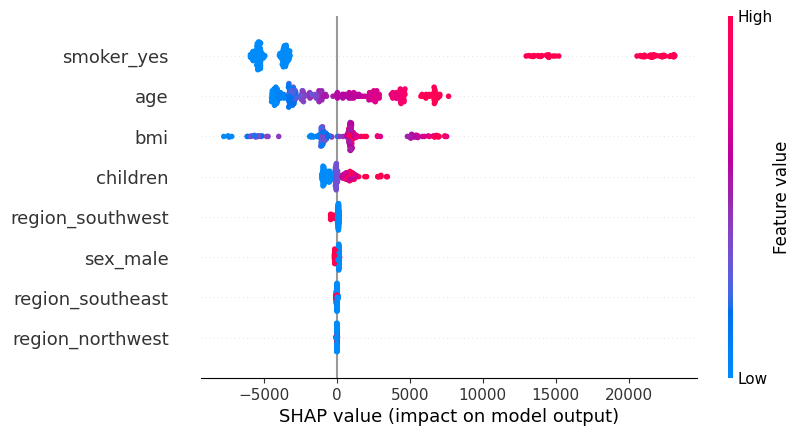

In [75]:
shap.plots.beeswarm(shap_values)

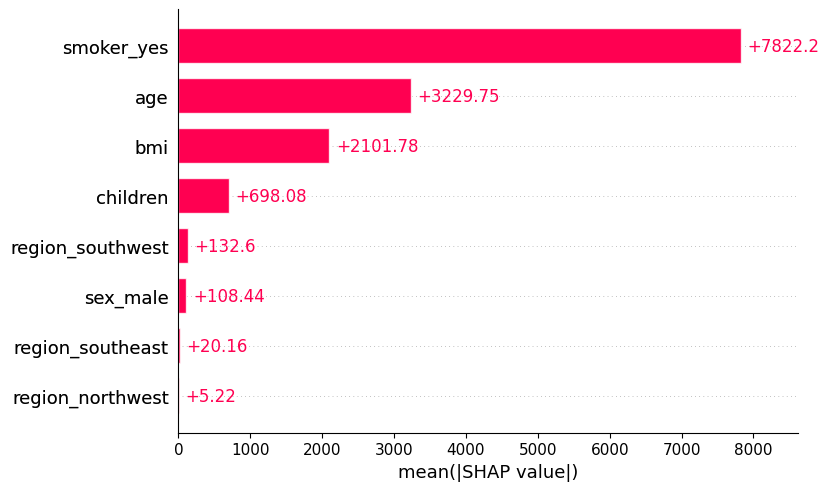

In [77]:
shap.plots.bar(shap_values)

In [79]:
sample = pd.DataFrame({
    'age':[30],
    'bmi':[28.5],
    'children':[2],
    'sex_male':[1],
    'smoker_yes':[0],
    'region_northwest':[0],
    'region_southeast':[1],
    'region_southwest':[0]
})

prediction = best_gb.predict(sample)

print(f"Predicted Insurance Cost: ${prediction[0]:.2f}")

Predicted Insurance Cost: $6705.16


In [81]:
print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
0.8439713885421911


In [83]:
print(r2_score(y_test, y_pred))

0.9026321878155356


In [85]:
import joblib

joblib.dump(best_gb, "healthcare_cost_model.pkl")
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']